In [13]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_gemma3:4b-it-qat_20250619_20:59:00.jsonl" #VQA1
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_without_noneoftheothers_alt_gemma3:4b-it-qat_20250622_23:17:00.jsonl" #VQA4
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_fixorder_video_fps_gemma3:4b-it-qat_20250710_23:13:00.jsonl" #VQA6
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_fixorder_video_fps_gemma3:4b-it-qat_20250711_16:16:00.jsonl" #VQA7
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_fixorder_video_fps_maxframes5_gemma3:4b-it-qat_20250712_10:20:00.jsonl" #VQA?? ~ VQA4 but new sampling method

#QA_GEN_GRAPHS = WORK_DIR / "outputs/responses_on_small_val_gemma3:4b-it-qat_20250609_21:50:00.jsonl" #GQA1
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gu_on_sgg_union_oneframeprompt_gemma3:4b-it-qat_20250709_08:00:00.jsonl" #GQA6
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_all_sgg_20250711_16:11:00.jsonl" #GQA7
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_all_sgg_20250711_16:11:00.jsonl" #GQA8
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_oneframeprompt_sgg_20250708_10:37:00.jsonl" #GQA9
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_oneframeprompt_maxframes5_sgg_20250605_11:09:00.jsonl" #GQA10
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_all_sgg_20250712_09:55:00.jsonl" #GQA11
#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u4_all_sgg_20250712_09:55:00.jsonl" #GQA12


# new tests
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_fps_maxframes5_internVL3_20250715_12:06:00.jsonl" #internVL3
#VQA_RESP_FILEPATH = WORK_DIR / "outputs/vqa_u3_qwen2.5vl_1000_20250723_15:02:00.jsonl" #Qwen2.5VL 1000 samples

#QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_qwensgg_of_20240722_gemma3:4b-it-qat_20250730_10:21:00.jsonl" #Gemma3 GQA on Qwen SGG
QA_GEN_GRAPHS = WORK_DIR / "outputs/gqa_u3_qwensgg_of_20240722_qwen25vl:7b_20250730_10:21:00.jsonl" #Qwen2.5VL GQA on Qwen SGG


#VQA_RESP_FILEPATH = WORK_DIR / "notebooks/gemini_vqa_small200_20250722_15:44:00.jsonl" #Gemini2.5-flash
#VQA_RESP_FILEPATH = WORK_DIR / "scripts/data/vqa_gemini_flash_full_chat_history.jsonl" #Gemini2.5-flash
#QA_GEN_GRAPHS = WORK_DIR / "scripts/test_data/aggregated_final_gu_200_gemini_on_gemini_sgg.jsonl" #Gemini2.5-flash QA on SGG
VQA_RESP_FILEPATH = WORK_DIR / "scripts/data/aggregated_final_vqa_gemini_flash.jsonl" #Gemini2.5-flash

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


## Load GT

# Experiment
### Comparison between VQA and QA on generated frames - same sample rate


**Parameters:**
- model: Gemma3:4b-it-qat
- user_prompt: vqa/user_prompt_v2.txt
- temperature: 0.1
- sampling method: (default) top-p (p=0.9)

## Loading predicted answers evaluation

In [5]:
gt_df = None
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


In [ ]:
with VQA_RESP_FILEPATH.open() as f:
    data = pd.read_json(f, lines=True)


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   key         1040 non-null   object
 1   request     1040 non-null   object
 2   response_x  1040 non-null   object
 3   response_y  1040 non-null   object
dtypes: object(4)
memory usage: 32.6+ KB


In [15]:
pred_vqa_df = rp.ans_extract(VQA_RESP_FILEPATH, model="gemma3", format="gemini")
#pred_gg_df = rp.ans_extract(QA_GEN_GRAPHS, "gemma3", format="ollama")


Total answers: 1040
Answers following JSON template: 0
Percentage following JSON template: 0.00%


ValueError: Columns must be same length as key

In [13]:
for _, row in pred_gg_df[~pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])


{"answer": "None of the above."}
```json
{"answer": "None of the above"}
```
{"answer": "None of the alternatives (A, B, C, D) are supported by the scene graph."}
{"answer": "The question cannot be answered based on the provided STSG."}
```json
{"answer": "The question cannot be answered with the provided options."}
```
```json
{"answer": "None of the provided alternatives (A, B, C, D) are supported by the scene graph evidence."}
```
{"answer": "The question cannot be answered with the given STSG evidence."}
{"answer": "None of the provided options (A, B, C, D) are supported by the STSG."}
```json
{"answer": "No action can be determined from the given STSG."}
```
{"answer": "No answer can be provided based on the given STSG."}
```json
{"answer": "None of the alternatives (A, B, C, D) can be supported by the STSG evidence."}
```
{"answer": "The question cannot be answered with the given alternatives based on the provided STSG."}
{"answer": "The question cannot be answered with the given

In [14]:
pred_vqa_df = pred_vqa_df[pred_vqa_df['contains_answer']]
pred_gg_df = pred_gg_df[pred_gg_df['contains_answer']]


In [15]:
pred_vqa_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    pred_vqa_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          281        64.41%  
Sequence             277        70.04%  
Prediction           222        62.61%  
Feasibility          195        51.79%  

Average              975        63.08%  


In [16]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          298        94.30%  
Sequence             291        95.19%  
Prediction           239        92.89%  
Feasibility          220        88.64%  
Overall             1048        93.03%  


In [17]:
pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          174        59.20%  
Sequence             115        61.74%  
Prediction           129        49.61%  
Feasibility          112        50.00%  

Average              530        55.47%  


In [18]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        58.39%  
Sequence             291        39.52%  
Prediction           239        53.97%  
Feasibility          220        50.91%  
Overall             1048        50.57%  


In [19]:
print(pred_gg_df.iloc[0]["chat_history"][1]["content"])


### Question Interpretation:
The question asks which object the person is able to throw after walking through the doorway. This implies that the person must be holding an object in their hands and that the object must be something they can throw.

### STSG Analysis:
1. **Frame 0**: The person is standing in the closet, holding a black object in both hands.
2. **Frame 1**: The person is still holding the black object with both hands.
3. **Frame 2**: The person is holding the black object with one hand.
4. **Frame 3**: The person is still holding the black object with one hand.
5. **Frame 4**: The person is still holding the black object with one hand.

### Alternative Evaluation:
- **A. The bag**: There is no mention of a bag in the scene graph. The person is holding a black object, which is not identified as a bag.
- **B. The book**: There is no mention of a book in the scene graph. The person is holding a black object, which is not identified as a book.
- **C. The blanket**: There is 

## Gemini tests

In [20]:
VQA_RESP_FILEPATH = WORK_DIR / "scripts/data/vqa_gemini_flash_full_chat_history.jsonl" #Gemini2.5-flash
QA_GEN_GRAPHS = WORK_DIR / "scripts/data/gu_200_gemini_on_gemini_sgg_chunk_01_2nd_chat_history.jsonl" #Gemini2.5-flash QA on SGG

pred_vqa_df = rp.ans_extract(VQA_RESP_FILEPATH, model="gemma3", format="gemini")
#pred_gg_df = rp.ans_extract(QA_GEN_GRAPHS, model="gemma3", format="gemini")

pred_vqa_df = pred_vqa_df[pred_vqa_df['contains_answer']]
#pred_gg_df = pred_gg_df[pred_gg_df['contains_answer']]


Error executing eval on: {  "answer": "The video shows the person opening a door and walking into another room. Subsequently, in the new room, the person approaches a desk and picks up a flat, circular object, which they then bring to their mouth. None of the provided alternatives perfectly align with the visual evidence as *immediately* after opening the door, the person simply walks through. However, looking at the subsequent distinct action sequence in the video after the door is opened and the person moves to the next room, the person picks up an item from the desk. The item is a flat, circular disk, not explicitly a shoe, sandwich, paper/notebook, or another closet/cabinet. Given the provided choices and the action of taking an object and bringing it to the mouth for consumption, the closest, although still not perfectly accurate, description of an action that happens *after* opening the door is related to taking an item. Let's re-evaluate if any option is *least* incorrect. Since

Total answers: 200
Answers following JSON template: 195
Percentage following JSON template: 97.50%
Answer with a valid alternative: 175
89.74% of the total

Invalid answers: 20


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


In [21]:
pred_vqa_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df1 = gt_df.join(
    pred_vqa_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df1, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          49         83.67%  
Sequence             44         84.09%  
Prediction           41         73.17%  
Feasibility          41         41.46%  

Average              175        71.43%  


Interaction          50         82.00%  
Sequence             50         74.00%  
Prediction           50         60.00%  
Feasibility          50         34.00%  

Average              200        62.50%  

In [22]:
rp.print_ans_perc(eval_df1, gt_df)


Question type       Total      Answered 

Interaction          298        16.44%  
Sequence             291        15.12%  
Prediction           239        17.15%  
Feasibility          220        18.64%  
Overall             1048        16.70%  


In [34]:
pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df2 = gt_df.join(
    pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df2, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          33         63.64%  
Sequence             23         65.22%  
Prediction           31         51.61%  
Feasibility          21         33.33%  

Average              108        54.63%  


In [35]:
rp.print_ans_perc(eval_df2, gt_df)


Question type       Total      Answered 

Interaction          298        11.07%  
Sequence             291        7.90%   
Prediction           239        12.97%  
Feasibility          220        9.55%   
Overall             1048        10.31%  


In [36]:
print(pred_gg_df.iloc[0]['chat_history'][0]['content'])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-1:
<scene_graph>
man ---- in ---- kitchen
wooden_cabinets ---- to_the_left_of ---- man
white_appliance ---- behind ---- man
camera ---- close_to ---- man
</scene_graph>

Frame 2-3:
<scene_graph>
man ---- moving_arm ---- towards_center
man ---- adjusting_body ---- towards_refrigerator
wooden_cabinets ---- to_the_left_of ---- man
white_refrigerator ---- behind ---- man
</scene_graph>

Frame 4:
<scene_graph>
man ---- facing ---- refrigerator
man ---- extending_arm_towards ---- refrigerator
man ---- holding ---- clear_glass
clear_glass ---- in ---- man's_left_hand
refrigerator ---- in ---- kitchen
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 5:
<scene_graph>
man ---- opening ---- refrigerator_door
man ---- looking_inside ---- refrigerator
refrigerator_door ---- open ---- refrigerator
refrigerator_inte

In [37]:
pred_vqa_df.rename(columns={'pred_text': 'pred_text1'}, inplace=True)
pred_gg_df.rename(columns={'pred_text': 'pred_text2'}, inplace=True)
eval_df_all = gt_df.join(
    pred_vqa_df[['pred_text1']],
    how='inner'
).join(
    pred_gg_df[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all


,question,video_id,start,end,text,question_program,choices,situations,pred_text1,pred_text2
Prediction_T1_622,What will the person do next?,BFH78,7.7,15.775,open the book.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Open the book.', ...","{'000449': {'rel_pairs': [['o000', 'o017'], ['...",open the book.,take the food.
Interaction_T1_2354,Which object was put down by the person?,WOD0G,10.8,20.200,the towel.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The dish.', 'choi...","{'000348': {'rel_pairs': [['o000', 'o006'], ['...",the towel.,the dish.
Prediction_T4_1805,Which object would the person close next after...,1E7VU,3.5,13.625,the closet/cabinet.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The closet/cabine...","{'000120': {'rel_pairs': [['o000', 'o014'], ['...",the closet/cabinet.,the closet/cabinet.
Interaction_T1_4527,Which object was taken by the person?,TOOYI,0.5,5.700,the blanket.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The dish.', 'choi...","{'000136': {'rel_pairs': [['o000', 'o027'], ['...",the blanket.,the laptop.
Prediction_T3_1030,Which object would the person eat next?,ZOMM2,18.4,24.625,the sandwich.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The sandwich.', '...","{'000661': {'rel_pairs': [['o000', 'o010'], ['...",the medicine.,the sandwich.
...,...,...,...,...,...,...,...,...,...,...
Interaction_T1_4703,Which object was taken by the person?,TETZ7,12.5,19.500,the phone/camera.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The broom.', 'cho...","{'000434': {'rel_pairs': [['o000', 'o014'], ['...",the phone/camera.,the phone/camera.
Interaction_T1_8274,Which object was taken by the person?,HL5OP,19.0,27.900,the dish.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The towel.', 'cho...","{'000342': {'rel_pairs': [['o000', 'o024']], '...",the dish.,the dish.
Interaction_T1_8913,Which object was taken by the person?,F9YMU,11.9,16.500,the paper/notebook.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'The paper/noteboo...","{'000213': {'rel_pairs': [['o000', 'o006'], ['...",the paper/notebook.,the paper/notebook.
Interaction_T2_1847,What did the person do with the paper/notebook?,1TIAK,8.3,12.500,took.,"[{'function': 'Situations', 'value_input': []}...","[{'choice_id': 0, 'choice': 'Put down.', 'choi...","{'000210': {'rel_pairs': [['o000', 'o011']], '...",put down.,took.


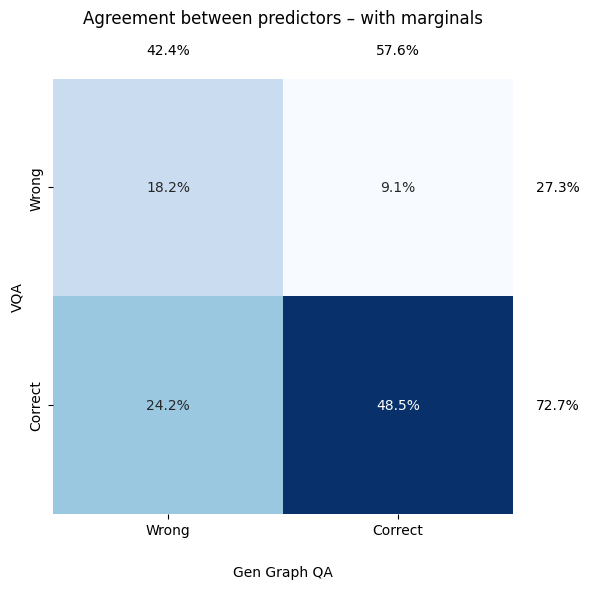

(99, 10)


In [38]:
# your data
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gen Graph QA', labelpad=20)
ax.set_ylabel('VQA')
ax.set_title('Agreement between predictors – with marginals', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)
